
===== RANDOM FOREST =====
Accuracy: 0.9937

Classification Report:
              precision    recall  f1-score   support

         low       1.00      1.00      1.00       545
    moderate       0.99      1.00      0.99       575
        high       0.99      0.96      0.97       147

    accuracy                           0.99      1267
   macro avg       0.99      0.99      0.99      1267
weighted avg       0.99      0.99      0.99      1267



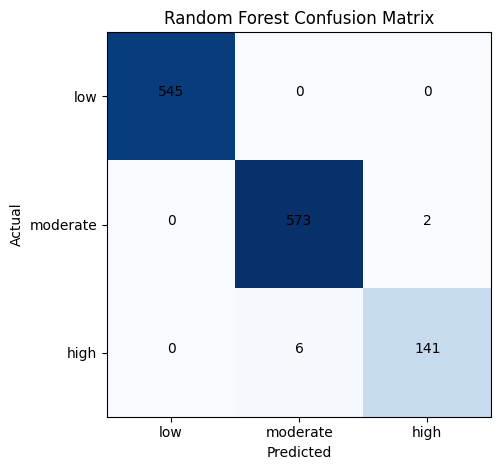

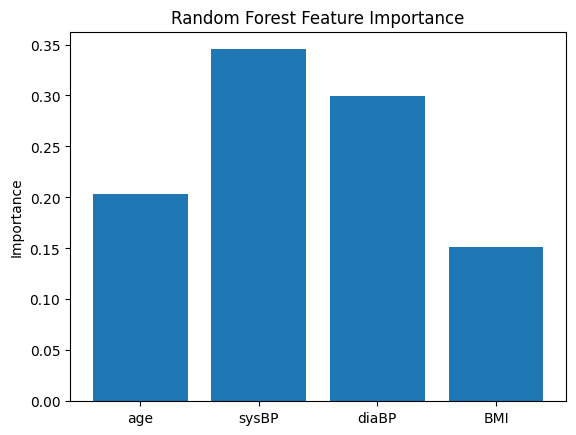

Cross-validation scores: [0.98984772 0.98984772 0.97969543 0.98646362 0.99152542]
Average CV accuracy: 0.9874759815308728


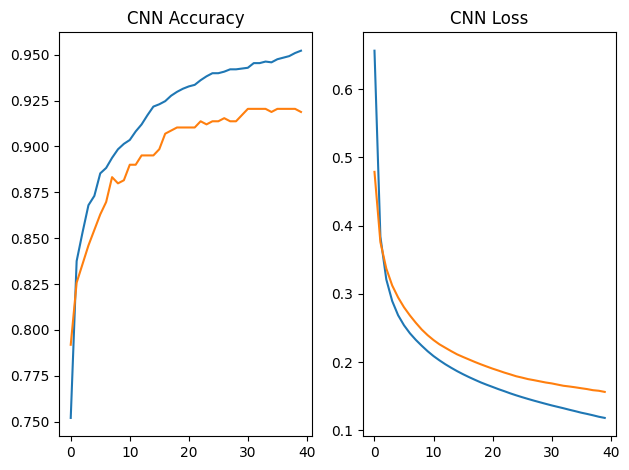

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== CNN =====
Accuracy: 0.9424

Classification Report:
              precision    recall  f1-score   support

         low       0.98      0.96      0.97       545
    moderate       0.91      0.96      0.94       575
        high       0.94      0.81      0.87       147

    accuracy                           0.94      1267
   macro avg       0.94      0.91      0.92      1267
weighted avg       0.94      0.94      0.94      1267



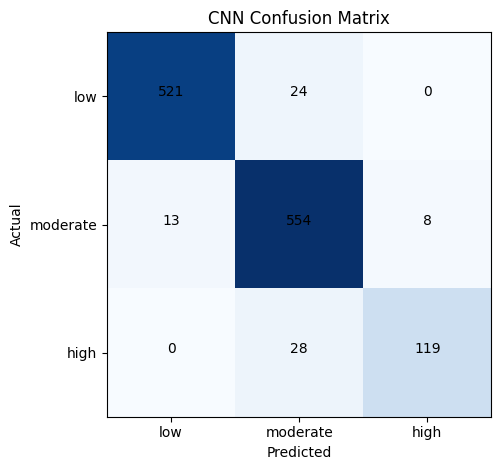

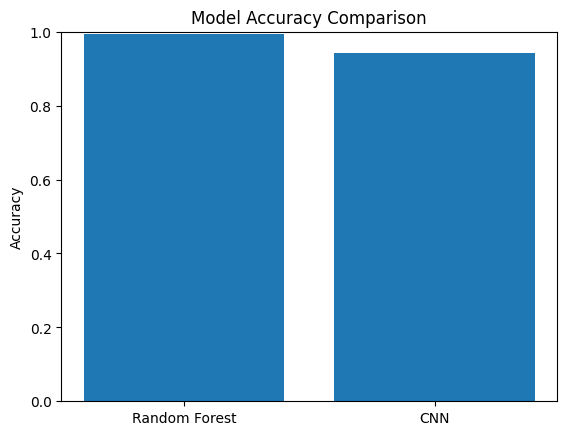

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

# ---------------- CONFIG ----------------
DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
FEATURES = ["age", "sysBP", "diaBP", "BMI"]
CLASSES = ["low", "moderate", "high"]
SEED = 42

# Reproducible results across NumPy/TensorFlow/sklearn splits.
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------- RISK LOGIC ----------------
def bp_points(sys, dia):
    if sys >= 180 or dia >= 120: return 4
    if sys >= 140 or dia >= 90: return 3
    if sys >= 130 or dia >= 80: return 2
    if sys >= 120 and dia < 80: return 1
    return 0

def age_points(age):
    return 2 if age >= 65 else 1 if age >= 45 else 0

def bmi_points(bmi):
    return 2 if bmi >= 35 else 1 if bmi >= 30 else 0

def score_to_label(score):
    if score <= 2: return "low"
    if score <= 4: return "moderate"
    return "high"

def build_labels(df):
    scores = (
        df.apply(lambda r: bp_points(r.sysBP, r.diaBP), axis=1)
        + df.age.apply(age_points)
        + df.BMI.apply(bmi_points)
    )
    return scores.apply(score_to_label)

# ---------------- PLOTS ----------------
def plot_confusion(y_true, y_pred, title):
    # Force consistent class order so axes always match labels.
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(CLASSES)), CLASSES)
    plt.yticks(range(len(CLASSES)), CLASSES)

    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            plt.text(j, i, cm[i, j], ha="center")

    plt.tight_layout()
    plt.show()

def plot_training(history):
    plt.figure()

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("CNN Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("CNN Loss")

    plt.tight_layout()
    plt.show()

def plot_feature_importance(importances):
    plt.figure()
    plt.bar(FEATURES, importances)
    plt.title("Random Forest Feature Importance")
    plt.ylabel("Importance")
    plt.show()

# ---------------- MAIN ----------------
def main():
    df = pd.read_csv(DATA_URL)
    # Keep project-only features and remove rows with missing values.
    df = df[FEATURES].dropna()
    df["risk"] = build_labels(df)

    X = df[FEATURES]
    y = df["risk"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=SEED
    )

    # Keep raw split for leakage-free cross-validation later.
    X_train_raw = X_train.copy()

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_train = pipeline.fit_transform(X_train)
    X_test = pipeline.transform(X_test)

    # ---------------- RANDOM FOREST ----------------
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
    rf.fit(X_train, y_train)

    rf_preds = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_preds)

    print("\n===== RANDOM FOREST =====")
    print(f"Accuracy: {rf_acc:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            rf_preds,
            labels=CLASSES,
            target_names=CLASSES,
            zero_division=0,
        )
    )

    plot_confusion(y_test, rf_preds, "Random Forest Confusion Matrix")

    # Feature importance
    plot_feature_importance(rf.feature_importances_)

    # Cross-validation with preprocessing inside the pipeline avoids leakage.
    rf_cv_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=300, random_state=SEED))
    ])
    cv_scores = cross_val_score(rf_cv_pipeline, X_train_raw, y_train, cv=5)
    print("Cross-validation scores:", cv_scores)
    print("Average CV accuracy:", cv_scores.mean())

    # ---------------- CNN ----------------
    label_map = {c:i for i,c in enumerate(CLASSES)}
    inv_map = {i:c for c,i in label_map.items()}

    y_train_enc = tf.keras.utils.to_categorical(
        y_train.map(label_map), num_classes=len(CLASSES)
    )

    X_train_cnn = X_train.reshape(-1, len(FEATURES), 1)
    X_test_cnn = X_test.reshape(-1, len(FEATURES), 1)

    cnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(FEATURES),1)),
        tf.keras.layers.Conv1D(32,2,activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(len(CLASSES), activation='softmax')
    ])

    cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )

    history = cnn.fit(
        X_train_cnn,
        y_train_enc,
        epochs=40,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    plot_training(history)

    probs = cnn.predict(X_test_cnn)
    preds = np.argmax(probs, axis=1)
    preds = np.array([inv_map[i] for i in preds])

    cnn_acc = accuracy_score(y_test, preds)

    print("\n===== CNN =====")
    print(f"Accuracy: {cnn_acc:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            preds,
            labels=CLASSES,
            target_names=CLASSES,
            zero_division=0,
        )
    )

    plot_confusion(y_test, preds, "CNN Confusion Matrix")

    # ---------------- FINAL COMPARISON ----------------
    models = ["Random Forest", "CNN"]
    accuracies = [rf_acc, cnn_acc]

    plt.figure()
    plt.bar(models, accuracies)
    plt.title("Model Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.show()

if __name__ == "__main__":
    main()